# 03 — Feature Engineering

**Girdi:** `data/csv/cleaned_dataset.csv` (02_data_cleaning çıktısı)  
**Çıktılar:**
- `data/csv/featured_dataset.csv` — seçilmiş özellikler + encodlanmış label
- `data/csv/selected_features.txt` — kullanılan özellik listesi (model notebook'ları için)
- `data/csv/label_mapping.csv` — integer ↔ string label eşlemesi

## Bu Notebook'ta Yapılanlar

| Adım | İşlem | Gerekçe |
|------|--------|---------|
| 1 | Dataset yükleme + özet | Baseline |
| 2 | Duplicate sütun tespiti ve silme | CIC-IDS2017 bilinen hatası (R7) |
| 3 | Yüksek korelasyon analizi ve silme | Multicollinearity azaltma |
| 4 | Mutual Information ile feature importance | Model-agnostic, non-linear ilişkileri yakalar |
| 5 | Düşük önem skoru filtresi | Gürültülü özellikleri çıkar |
| 6 | Label encoding (multiclass + binary) | sklearn uyumluluğu |
| 7 | Çarpıklık (skewness) raporu | Modeling notebook için referans |
| 8 | Görselleştirme | Korelasyon haritası + feature importance |
| 9 | Kalite kontrol assert'leri | Sessiz hataları önle |
| 10 | Kaydetme | 04_modeling girdisi |

**Kapsam dışı (04_modeling'e bırakıldı):** Feature scaling, SMOTE/oversampling,
train/test split. Tree-based modeller scaling gerektirmediğinden ve split stratejisi
modelin türüne göre farklılaşabileceğinden bu kararlar modeling notebook'unda alınacak.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("=" * 50)
print("Kutuephaneler yueklendi v")
print(f"  Pandas   : {pd.__version__}")
print(f"  NumPy    : {np.__version__}")
print("=" * 50)

Kutuephaneler yueklendi v
  Pandas   : 2.3.3
  NumPy    : 2.4.1


## 1. Dataset Yuekleme

In [2]:
INPUT_PATH          = "../data/csv/cleaned_dataset.csv"
OUTPUT_DATASET      = "../data/csv/featured_dataset.csv"
OUTPUT_FEATURES_TXT = "../data/csv/selected_features.txt"
OUTPUT_LABEL_MAP    = "../data/csv/label_mapping.csv"

df = pd.read_csv(INPUT_PATH, low_memory=False)

print("=" * 65)
print("TEMIZLENMIS DATASET YUEKLENDI (02 notebook ciktisi)")
print("=" * 65)
print(f"  Satir       : {df.shape[0]:>9,}")
print(f"  Sutun       : {df.shape[1]}")
print(f"  Bellek      : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric  = [c for c in df.columns if c not in numeric_cols]
print(f"  Numerik sutun sayisi    : {len(numeric_cols)}")
print(f"  Non-numerik sutunlar    : {non_numeric}")
print()
print("Sinif dagilimi:")
label_dist = df["Label"].value_counts()
for label, cnt in label_dist.items():
    pct = cnt / len(df) * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

TEMIZLENMIS DATASET YUEKLENDI (02 notebook ciktisi)
  Satir       :   495,855
  Sutun       : 72
  Bellek      : 335.2 MB

  Numerik sutun sayisi    : 70
  Non-numerik sutunlar    : ['Label', 'source_file']

Sinif dagilimi:
  BENIGN                                    383,341  (%77.3)
  DDoS                                       29,998  (% 6.0)
  PortScan                                   25,483  (% 5.1)
  DoS Hulk                                   22,915  (% 4.6)
  DoS GoldenEye                              10,286  (% 2.1)
  FTP-Patator                                 5,931  (% 1.2)
  DoS slowloris                               5,384  (% 1.1)
  DoS Slowhttptest                            5,228  (% 1.1)
  SSH-Patator                                 3,219  (% 0.6)
  Bot                                         1,948  (% 0.4)
  Web Attack - Brute Force                    1,470  (% 0.3)
  Web Attack - XSS                              652  (% 0.1)


## 2. Duplicate Sutun Tespiti ve Silme

**Gecekce:** CIC-IDS2017'de `Fwd Header Length` ve `Fwd Header Length.1` sutunlari
ozdes degerler icerir (R7 - CICFlowMeter uretim hatasi). Bu tur duplikasyonlar
korelasyon analizini bozar ve modeli o ozelligi iki kez agirliklandirmaya iter.
Duplicate tespiti deger bazinda yapilir; sadece isim benzerligine guvenilmez.

In [3]:
print("=" * 60)
print("DUPLICATE SUTUN TESPITI")
print("=" * 60)

# Transpoz alarak sutun karsilastirmasi yap
df_T = df[numeric_cols].T
duplicate_mask = df_T.duplicated(keep="first")
duplicate_cols = df_T[duplicate_mask].index.tolist()
original_cols  = df_T[~duplicate_mask].index.tolist()

if duplicate_cols:
    print(f"Ozdes deger iceren duplicate sutunlar ({len(duplicate_cols)} adet):")
    for dup in duplicate_cols:
        for orig in original_cols:
            if df[dup].equals(df[orig]):
                print(f"  '{dup}'  ==  '{orig}'  -> '{dup}' siliniyor")
                break
    df.drop(columns=duplicate_cols, inplace=True)
    print(f"\n-> {len(duplicate_cols)} duplicate sutun silindi. Kalan: {df.shape[1]}")
else:
    print("v Duplicate sutun yok")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerik ozellik sayisi: {len(numeric_cols)}")

DUPLICATE SUTUN TESPITI
Ozdes deger iceren duplicate sutunlar (7 adet):
  'SYN Flag Count'  ==  'Fwd PSH Flags'  -> 'SYN Flag Count' siliniyor
  'CWE Flag Count'  ==  'Fwd URG Flags'  -> 'CWE Flag Count' siliniyor
  'ECE Flag Count'  ==  'RST Flag Count'  -> 'ECE Flag Count' siliniyor
  'Avg Fwd Segment Size'  ==  'Fwd Packet Length Mean'  -> 'Avg Fwd Segment Size' siliniyor
  'Fwd Header Length.1'  ==  'Fwd Header Length'  -> 'Fwd Header Length.1' siliniyor
  'Subflow Fwd Packets'  ==  'Total Fwd Packets'  -> 'Subflow Fwd Packets' siliniyor
  'Subflow Bwd Packets'  ==  'Total Backward Packets'  -> 'Subflow Bwd Packets' siliniyor

-> 7 duplicate sutun silindi. Kalan: 65

Numerik ozellik sayisi: 63


## 3. Yuksek Korelasyon Analizi ve Silme

**Akademik gececke:** Pearson korelasyonu |r| > 0.98 olan ozellik ciftlerinden biri
kaldirilir (greedy: once gelen tutulur). Bu esik RFC (2019) ve benzeri IDS
calismalarinda yaygin kullanilir.
- 0.95: Daha agresif, bilgi kaybi riski artar
- **0.98: Asiri bilgi kaybi olmaksizin cok dogrusal bagimliligi kirar (tercihimiz)**
- 0.99: Cok muhafazakar, redundant ozellikler kalabilir

Yontem: ust ucgen korelasyon matrisinde esigi asan ciftleri bul, greedy olarak
ikinci sutunu drop listesine ekle.

In [4]:
CORR_THRESHOLD = 0.98

print("=" * 60)
print(f"YUKSEK KORELASYON ANALIZI (esik: |r| > {CORR_THRESHOLD})")
print("=" * 60)

corr_matrix = df[numeric_cols].corr(method="pearson").abs()

# Ust ucgen (kendisi haric)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Esigi asan ciftleri bul
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD
]

# Greedy drop listesi
to_drop_corr = set()
for col1, col2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    if col1 not in to_drop_corr and col2 not in to_drop_corr:
        to_drop_corr.add(col2)

print(f"Yuksek korelasyonlu cift sayisi : {len(high_corr_pairs)}")
print(f"Drop edilecek sutun sayisi      : {len(to_drop_corr)}")
print()

if high_corr_pairs:
    print(f"  {'Tutulan':<35} {'Silinen':<35} {'r':>6}")
    print("-" * 80)
    shown = set()
    for col1, col2, r in sorted(high_corr_pairs, key=lambda x: -x[2])[:25]:
        if col2 in to_drop_corr:
            kept, dropped = col1, col2
        elif col1 in to_drop_corr:
            kept, dropped = col2, col1
        else:
            continue
        key = (kept, dropped)
        if key not in shown:
            print(f"  {kept:<35} {dropped:<35} {r:.4f}")
            shown.add(key)
    if len(high_corr_pairs) > 25:
        print(f"  ... (toplam {len(high_corr_pairs)} cift, ilk 25 gosterildi)")

YUKSEK KORELASYON ANALIZI (esik: |r| > 0.98)
Yuksek korelasyonlu cift sayisi : 20
Drop edilecek sutun sayisi      : 14

  Tutulan                             Silinen                                  r
--------------------------------------------------------------------------------
  Avg Bwd Segment Size                Bwd Packet Length Mean              1.0000
  Subflow Bwd Bytes                   Total Length of Bwd Packets         1.0000
  Subflow Fwd Bytes                   Total Length of Fwd Packets         1.0000
  Bwd Header Length                   Fwd Header Length                   1.0000
  Total Backward Packets              Total Fwd Packets                   0.9995
  Total Length of Bwd Packets         Total Backward Packets              0.9986
  Subflow Bwd Bytes                   Total Backward Packets              0.9986
  Fwd IAT Total                       Flow Duration                       0.9982
  Average Packet Size                 Packet Length Mean              

In [5]:
before_corr = df.shape[1]
df.drop(columns=list(to_drop_corr), inplace=True)
after_corr  = df.shape[1]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Sutun: {before_corr} -> {after_corr}  ({before_corr - after_corr} sutun silindi)")
print(f"Kalan numerik ozellik sayisi: {len(numeric_cols)}")

Sutun: 65 -> 51  (14 sutun silindi)
Kalan numerik ozellik sayisi: 49


KORELASYON YÖN ANALİZİ

POZİTİF yüksek korelasyon (r > 0.5): 72 çift
→ Bu çiftler AYNI YÖNDE hareket ediyor.
  (Biri artınca diğeri de artıyor — örn: paket boyutu ↑, akış boyutu ↑)

NEGATİF yüksek korelasyon (r < -0.5): 0 çift
→ Bu çiftler ZIT YÖNDE hareket ediyor.
  (Biri artınca diğeri azalıyor — örn: paket hızı ↑, paket süresi ↓)



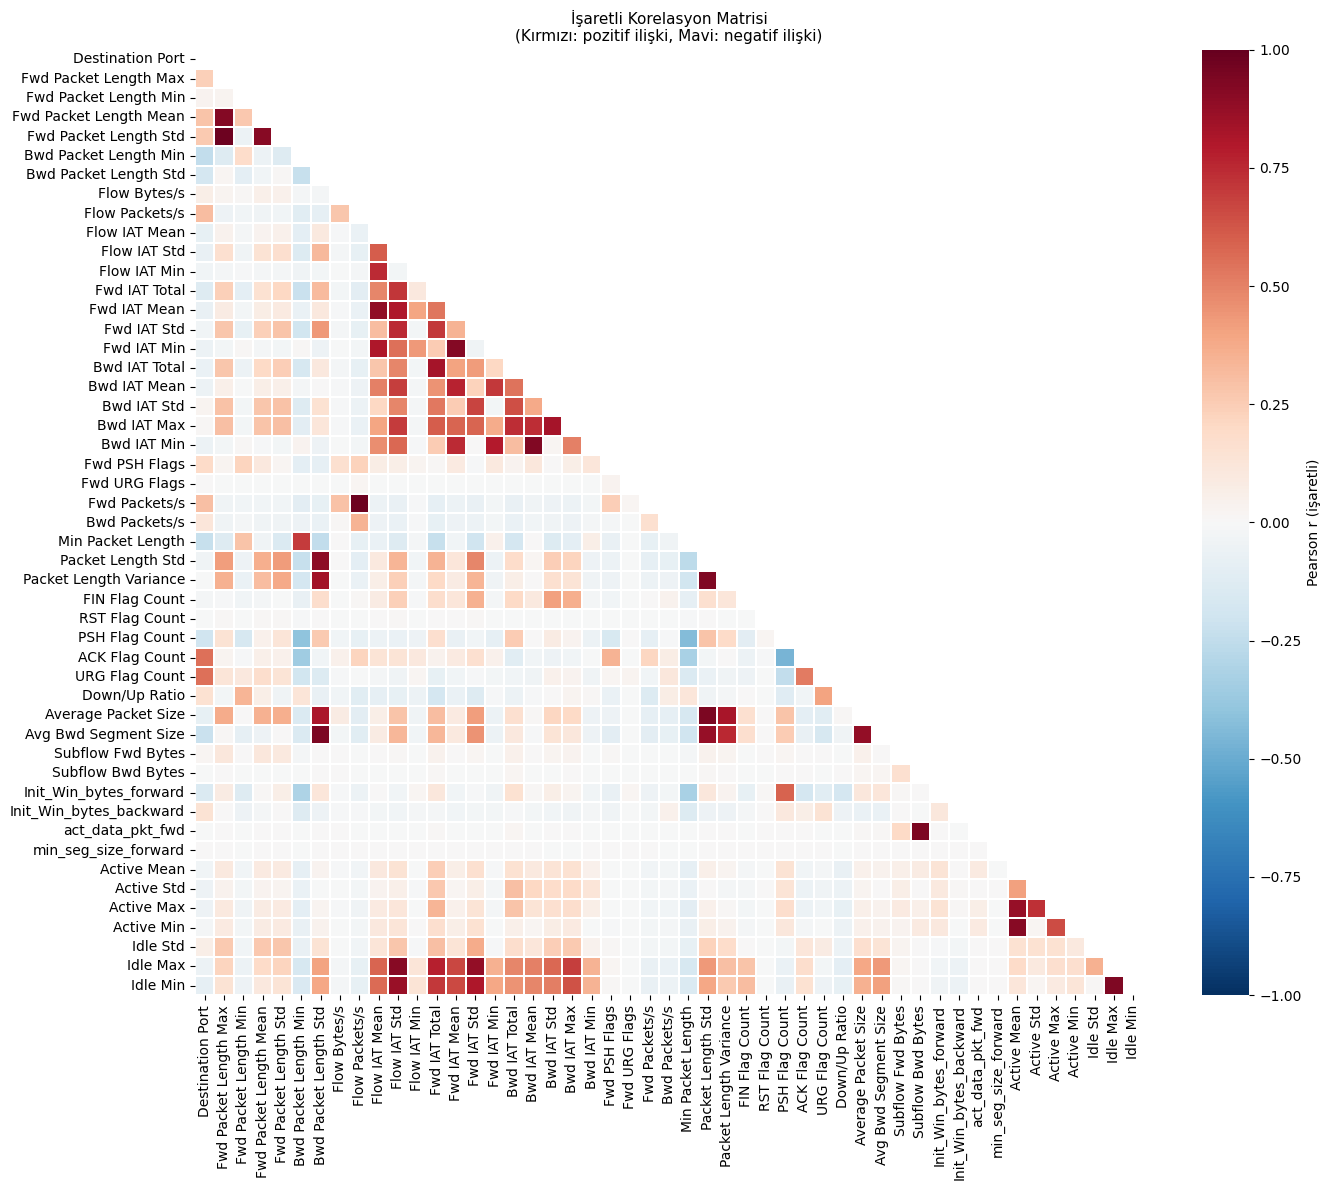

✓ İşaretli korelasyon haritası kaydedildi.

✓ Güçlü negatif korelasyon (r < -0.5) yok — bu CIC-IDS2017 için tipik.
  Çoğu özellik ya pozitif korelasyonlu ya da bağımsız.


In [7]:
# ── Korelasyon Yön Analizi (Signed Correlation) ───────────────────────────
print("=" * 70)
print("KORELASYON YÖN ANALİZİ")
print("=" * 70)

# İşaretli korelasyon matrisi (abs olmadan) - DEĞİŞKEN İSMİ DÜZELTİLDİ (numeric_cols)
corr_signed = df[numeric_cols].corr(method="pearson")

# Pozitif yüksek korelasyonlar (r > 0.5)
upper_signed = corr_signed.where(
    np.triu(np.ones(corr_signed.shape), k=1).astype(bool)
)

pos_pairs = [(c, r, upper_signed.loc[r, c])
             for c in upper_signed.columns
             for r in upper_signed.index
             if pd.notna(upper_signed.loc[r, c])
             and upper_signed.loc[r, c] > 0.5]

neg_pairs = [(c, r, upper_signed.loc[r, c])
             for c in upper_signed.columns
             for r in upper_signed.index
             if pd.notna(upper_signed.loc[r, c])
             and upper_signed.loc[r, c] < -0.5]

print(f"\nPOZİTİF yüksek korelasyon (r > 0.5): {len(pos_pairs)} çift")
print("→ Bu çiftler AYNI YÖNDE hareket ediyor.")
print("  (Biri artınca diğeri de artıyor — örn: paket boyutu ↑, akış boyutu ↑)\n")

print(f"NEGATİF yüksek korelasyon (r < -0.5): {len(neg_pairs)} çift")
print("→ Bu çiftler ZIT YÖNDE hareket ediyor.")
print("  (Biri artınca diğeri azalıyor — örn: paket hızı ↑, paket süresi ↓)\n")

# Görsel: Signed heatmap (sadece final numeric_cols için)
if len(numeric_cols) <= 50:
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_signed.loc[numeric_cols, numeric_cols], dtype=bool))
    sns.heatmap(
        corr_signed.loc[numeric_cols, numeric_cols],
        mask=mask,
        cmap="RdBu_r",      # Kırmızı=pozitif, Mavi=negatif
        center=0,
        vmin=-1, vmax=1,
        annot=False,
        ax=ax,
        linewidths=0.3,
        cbar_kws={"label": "Pearson r (işaretli)"}
    )
    ax.set_title(
        "İşaretli Korelasyon Matrisi\n"
        "(Kırmızı: pozitif ilişki, Mavi: negatif ilişki)",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig("../data/csv/signed_correlation_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ İşaretli korelasyon haritası kaydedildi.")

# Negatif çiftlerin listesi (varsa)
if neg_pairs:
    print("\nNegatif korelasyonlu çiftler:")
    for c1, c2, r in sorted(neg_pairs, key=lambda x: x[2])[:10]:
        print(f"  {c1:<35} ↕ {c2:<35}  r={r:.4f}")
else:
    print("\n✓ Güçlü negatif korelasyon (r < -0.5) yok — bu CIC-IDS2017 için tipik.")
    print("  Çoğu özellik ya pozitif korelasyonlu ya da bağımsız.")

## 4. Mutual Information ile Feature Importance

**Akademik gececke:** Mutual Information (MI), ozellik ile hedef degisken arasindaki
bagimliligi dogrusal olmayan iliskileri de kapsayacak sekilde oelcer.
Pearson korelasyonuna kiyasla ag trafikindeki non-linear oruntuleri
(DoS burst, port scan sirasi) daha iyi yakalar.
Model-agnostic oldugu icin Random Forest, XGBoost veya MLP gibi farkli modeller
icin ortak bir temel feature siralamasini saglar.

**Uygulama:** `sklearn.feature_selection.mutual_info_classif`
Buyuk datasette hesap suresi yonetimi icin ornekleme uygulanir.

In [8]:
# MI hesabi icin label'i gecici encode et
le_temp = LabelEncoder()
y_encoded = le_temp.fit_transform(df["Label"])

# Buyuk datasette MI hesabi yavas olabilir -> ornekle
MI_SAMPLE = 100_000
if len(df) > MI_SAMPLE:
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(df), size=MI_SAMPLE, replace=False)
    X_mi = df[numeric_cols].values[idx]
    y_mi = y_encoded[idx]
    print(f"MI hesabi icin {MI_SAMPLE:,} satir orneklendi (toplam: {len(df):,})")
else:
    X_mi = df[numeric_cols].values
    y_mi = y_encoded
    print(f"MI hesabi tum {len(df):,} satir uzerinde yapiliyor")

print("MI hesaplaniyor... (bu biraz surebilir)")
mi_scores = mutual_info_classif(
    X_mi, y_mi,
    discrete_features=False,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    "feature" : numeric_cols,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print()
print("=" * 60)
print("MUTUAL INFORMATION -- ILK 20 OZELLIK")
print("=" * 60)
print(f"  {'#':<4} {'Ozellik':<45} {'MI Skoru':>10}")
print("-" * 65)
for i, row in mi_df.head(20).iterrows():
    print(f"  {i+1:<4} {row['feature']:<45} {row['mi_score']:>10.4f}")

print()
print("=" * 60)
print("EN DUSUK MI SKORLU OZELLIKLER (son 15)")
print("=" * 60)
for i, row in mi_df.tail(15).iterrows():
    print(f"  {i+1:<4} {row['feature']:<45} {row['mi_score']:>10.4f}")

MI hesabi icin 100,000 satir orneklendi (toplam: 495,855)
MI hesaplaniyor... (bu biraz surebilir)

MUTUAL INFORMATION -- ILK 20 OZELLIK
  #    Ozellik                                         MI Skoru
-----------------------------------------------------------------
  1    Average Packet Size                               0.7282
  2    Packet Length Std                                 0.6983
  3    Packet Length Variance                            0.6972
  4    Subflow Fwd Bytes                                 0.6369
  5    Subflow Bwd Bytes                                 0.6290
  6    Avg Bwd Segment Size                              0.6260
  7    Fwd Packet Length Max                             0.5905
  8    Init_Win_bytes_backward                           0.5554
  9    Fwd IAT Total                                     0.5407
  10   Init_Win_bytes_forward                            0.5356
  11   Fwd Packet Length Mean                            0.5331
  12   Fwd IAT Mean           

## 5. Dusuk MI Skor Filtresi

**Gececke:** MI skoru 0.01'in altinda olan ozellikler label ile istatistiksel olarak
bagimsizdir. Bu ozellikleri tutmak model karmasikligini arttirir, egitim suresini
uzatir ve overfitting riskini yukseltir.

Esik 0.01 pratik bir sinirdir (MI dagiliminin alt %5 kuyrugunun kesilmesi).
Hocanin yonlendirmesiyle daha katı/gevşek bir esik uygulanabilir.

In [9]:
MI_THRESHOLD = 0.01

low_mi_features = mi_df[mi_df["mi_score"] < MI_THRESHOLD]["feature"].tolist()

print("=" * 60)
print(f"DUSUK MI FILTRESI (esik: MI < {MI_THRESHOLD})")
print("=" * 60)

if low_mi_features:
    print(f"Cikarilan ozellikler ({len(low_mi_features)} adet):")
    for f in low_mi_features:
        score = mi_df.loc[mi_df["feature"] == f, "mi_score"].values[0]
        print(f"  - {f:<45} MI={score:.5f}")
    df.drop(columns=low_mi_features, inplace=True)
    print(f"\n-> {len(low_mi_features)} ozellik silindi.")
else:
    print(f"v MI < {MI_THRESHOLD} olan ozellik yok")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nKalan numerik ozellik sayisi: {len(numeric_cols)}")

DUSUK MI FILTRESI (esik: MI < 0.01)
Cikarilan ozellikler (2 adet):
  - RST Flag Count                                MI=0.00164
  - Fwd URG Flags                                 MI=0.00065

-> 2 ozellik silindi.

Kalan numerik ozellik sayisi: 47


## 6. Label Encoding

Iki ayri label sutunu olusturulur:

| Sutun | Aciklama | Kullanim |
|-------|----------|----------|
| `label_multiclass` | 0-N integer (LabelEncoder sirasi) | Cok sinifli siniflandirma |
| `label_binary` | 0=BENIGN, 1=ATTACK | Binary / anomaly detection |

Orijinal `Label` string sutunu korunur (aciklama ve hata analizi icin).

In [10]:
# Multiclass encoding
le = LabelEncoder()
df["label_multiclass"] = le.fit_transform(df["Label"])

# Esleme tablosu
label_mapping = pd.DataFrame({
    "label_int"   : range(len(le.classes_)),
    "label_string": le.classes_
})

# Binary encoding
df["label_binary"] = (df["Label"] != "BENIGN").astype(int)

print("=" * 55)
print("LABEL ENCODING")
print("=" * 55)
print()
print("Multiclass esleme (label_int -> label_string):")
for _, row in label_mapping.iterrows():
    cnt = (df["label_multiclass"] == row["label_int"]).sum()
    pct = cnt / len(df) * 100
    print(f"  {row['label_int']:>2}  ->  {row['label_string']:<40} {cnt:>8,}  (%{pct:4.1f})")

print()
n_benign_bin = (df["label_binary"] == 0).sum()
n_attack_bin = (df["label_binary"] == 1).sum()
print("Binary esleme (label_binary):")
print(f"  0  ->  BENIGN   {n_benign_bin:>9,}  (%{n_benign_bin/len(df)*100:.1f})")
print(f"  1  ->  ATTACK   {n_attack_bin:>9,}  (%{n_attack_bin/len(df)*100:.1f})")

LABEL ENCODING

Multiclass esleme (label_int -> label_string):
   0  ->  BENIGN                                    383,341  (%77.3)
   1  ->  Bot                                         1,948  (% 0.4)
   2  ->  DDoS                                       29,998  (% 6.0)
   3  ->  DoS GoldenEye                              10,286  (% 2.1)
   4  ->  DoS Hulk                                   22,915  (% 4.6)
   5  ->  DoS Slowhttptest                            5,228  (% 1.1)
   6  ->  DoS slowloris                               5,384  (% 1.1)
   7  ->  FTP-Patator                                 5,931  (% 1.2)
   8  ->  PortScan                                   25,483  (% 5.1)
   9  ->  SSH-Patator                                 3,219  (% 0.6)
  10  ->  Web Attack - Brute Force                    1,470  (% 0.3)
  11  ->  Web Attack - XSS                              652  (% 0.1)

Binary esleme (label_binary):
  0  ->  BENIGN     383,341  (%77.3)
  1  ->  ATTACK     112,514  (%22.7)


## 7. Çarpıklık (Skewness) Raporu — Bilgi Amaçlı

**Gececke:** Ag trafikinde paket boyutlari ve zaman araliklari cogunlukla saga carpik
dagilim gosterir (cok sayida kisa akis, az sayida uzun akis). Bu durum:
- **Tree-based modeller** (RF, XGBoost): Scaling ve carpiklik duzeltme gerekmez
- **SVM, KNN, MLP**: StandardScaler veya log1p donusumu onerilir

Bu adim sadece raporlar. Donusum karari 04_modeling'de model seciminden sonra alinir.

ÇARPIKLIK RAPORU -- SADECE BİLGİ (bu adimda donum yapilmaz)
  Yuksek carpiklik (|skew| > 10)       : 13 ozellik
  Orta carpiklik   (2 < |skew| <= 10)  : 31 ozellik
  Dusuk carpiklik  (|skew| <= 2)        : 3 ozellik

NOT: MLP/SVM kullanilacaksa log1p donusumu yuksek carpiklikli ozellikler
     icin 04_modeling'de uygulanmalidir.

  Ozellik                                         Skewness
----------------------------------------------------------
  min_seg_size_forward                             -681.74
  Subflow Fwd Bytes                                 628.84
  act_data_pkt_fwd                                  326.79
  Subflow Bwd Bytes                                 294.98
  Flow Bytes/s                                       46.57
  Active Min                                         27.20
  Active Mean                                        22.44
  Active Std                                         21.91
  Bwd Packets/s                                      21.05
  Flow IAT Min     

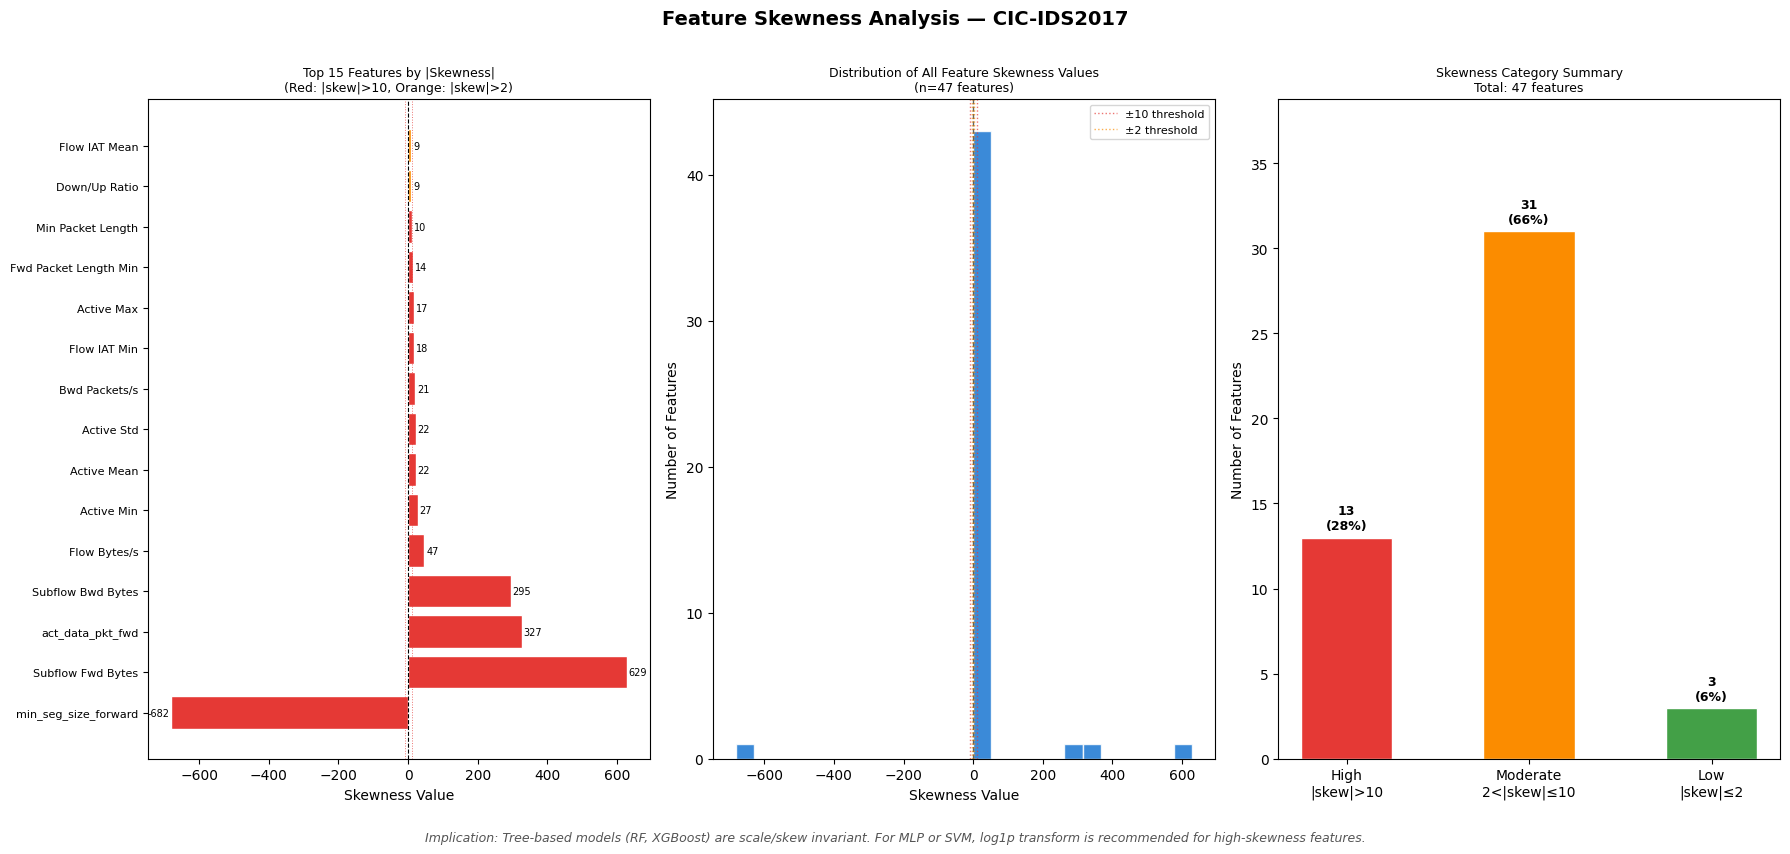

✓ Skewness plot saved: ../data/csv/skewness_plot.png


In [11]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("label_multiclass", "label_binary")]

skew_series = df[feature_cols].skew().sort_values(ascending=False)
high_skew   = skew_series[skew_series.abs() > 10].sort_values(key=abs, ascending=False)
mod_skew    = skew_series[(skew_series.abs() > 2) & (skew_series.abs() <= 10)]
low_skew    = skew_series[skew_series.abs() <= 2]

print("=" * 70)
print("ÇARPIKLIK RAPORU -- SADECE BİLGİ (bu adimda donum yapilmaz)")
print("=" * 70)
print(f"  Yuksek carpiklik (|skew| > 10)       : {len(high_skew)} ozellik")
print(f"  Orta carpiklik   (2 < |skew| <= 10)  : {len(mod_skew)} ozellik")
print(f"  Dusuk carpiklik  (|skew| <= 2)        : {len(low_skew)} ozellik")
print()
print("NOT: MLP/SVM kullanilacaksa log1p donusumu yuksek carpiklikli ozellikler")
print("     icin 04_modeling'de uygulanmalidir.")
print()

if len(high_skew) > 0:
    print(f"  {'Ozellik':<45} {'Skewness':>10}")
    print("-" * 58)
    for feat, skv in high_skew.head(15).items():
        print(f"  {feat:<45} {skv:>10.2f}")
    if len(high_skew) > 15:
        print(f"  ... ({len(high_skew)} ozellik toplam, ilk 15 gosterildi)")
        
# ── Skewness Visualization (English) ────────────────────────────────────────
feature_cols_skew = [c for c in df.select_dtypes(include=[np.number]).columns
                     if c not in ("label_multiclass", "label_binary")]

skew_series = df[feature_cols_skew].skew().sort_values(key=abs, ascending=False)

# Categorize
high_skew = skew_series[skew_series.abs() > 10]
mod_skew  = skew_series[(skew_series.abs() > 2) & (skew_series.abs() <= 10)]
low_skew  = skew_series[skew_series.abs() <= 2]

print("=" * 70)
print("SKEWNESS REPORT  (transformation applied only in modeling notebook)")
print("=" * 70)
print(f"  High skewness (|skew| > 10)      : {len(high_skew):>3} features")
print(f"  Moderate skewness (2 < |skew| ≤ 10): {len(mod_skew):>3} features")
print(f"  Low skewness (|skew| ≤ 2)          : {len(low_skew):>3} features")
print()
print("NOTE: For MLP/SVM, apply log1p transform to high-skewness features in 04_modeling.")

# ── Figure layout: 3 panels ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8))
fig.suptitle("Feature Skewness Analysis — CIC-IDS2017",
             fontsize=14, fontweight="bold", y=1.01)

# ── Panel 1: Top 15 most skewed (by |skew|) ──────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
top15 = skew_series.head(15)
colors_bar = ["#E53935" if abs(v) > 10 else "#FB8C00" for v in top15.values]
bars = ax1.barh(range(len(top15)), top15.values, color=colors_bar, edgecolor="white")
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15.index, fontsize=8)
ax1.axvline(0,   color="black",   linewidth=0.8, linestyle="--")
ax1.axvline(10,  color="#E53935", linewidth=0.7, linestyle=":",  alpha=0.7)
ax1.axvline(-10, color="#E53935", linewidth=0.7, linestyle=":",  alpha=0.7)
ax1.set_xlabel("Skewness Value")
ax1.set_title("Top 15 Features by |Skewness|\n"
              "(Red: |skew|>10, Orange: |skew|>2)", fontsize=9)
# Value labels on bars
for bar, val in zip(bars, top15.values):
    xpos = bar.get_width() + (5 if val >= 0 else -5)
    ha   = "left" if val >= 0 else "right"
    ax1.text(xpos, bar.get_y() + bar.get_height() / 2,
             f"{val:.0f}", va="center", ha=ha, fontsize=7)

# ── Panel 2: Histogram of all skewness values ─────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(skew_series.values, bins=25, color="#1976D2",
         edgecolor="white", alpha=0.85)
ax2.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax2.axvline(10,  color="#E53935", linewidth=1, linestyle=":", alpha=0.7,
            label="±10 threshold")
ax2.axvline(-10, color="#E53935", linewidth=1, linestyle=":", alpha=0.7)
ax2.axvline(2,   color="#FB8C00", linewidth=1, linestyle=":", alpha=0.7,
            label="±2 threshold")
ax2.axvline(-2,  color="#FB8C00", linewidth=1, linestyle=":", alpha=0.7)
ax2.set_xlabel("Skewness Value")
ax2.set_ylabel("Number of Features")
ax2.set_title("Distribution of All Feature Skewness Values\n"
              f"(n={len(skew_series)} features)", fontsize=9)
ax2.legend(fontsize=8)

# ── Panel 3: Category summary bar ────────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
categories  = ["High\n|skew|>10", "Moderate\n2<|skew|≤10", "Low\n|skew|≤2"]
cat_counts  = [len(high_skew), len(mod_skew), len(low_skew)]
cat_colors  = ["#E53935", "#FB8C00", "#43A047"]
bars3 = ax3.bar(categories, cat_counts, color=cat_colors,
                edgecolor="white", width=0.5)
for bar, cnt in zip(bars3, cat_counts):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{cnt}\n({cnt/len(skew_series)*100:.0f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_ylabel("Number of Features")
ax3.set_title("Skewness Category Summary\n"
              f"Total: {len(skew_series)} features", fontsize=9)
ax3.set_ylim(0, max(cat_counts) * 1.25)
ax3.axhline(0, color="black", linewidth=0.5)

# ── Implication note ─────────────────────────────────────────────────────────
fig.text(0.5, -0.03,
         "Implication: Tree-based models (RF, XGBoost) are scale/skew invariant. "
         "For MLP or SVM, log1p transform is recommended for high-skewness features.",
         ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("../data/csv/skewness_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Skewness plot saved: ../data/csv/skewness_plot.png")

## 8. Gorselletirme

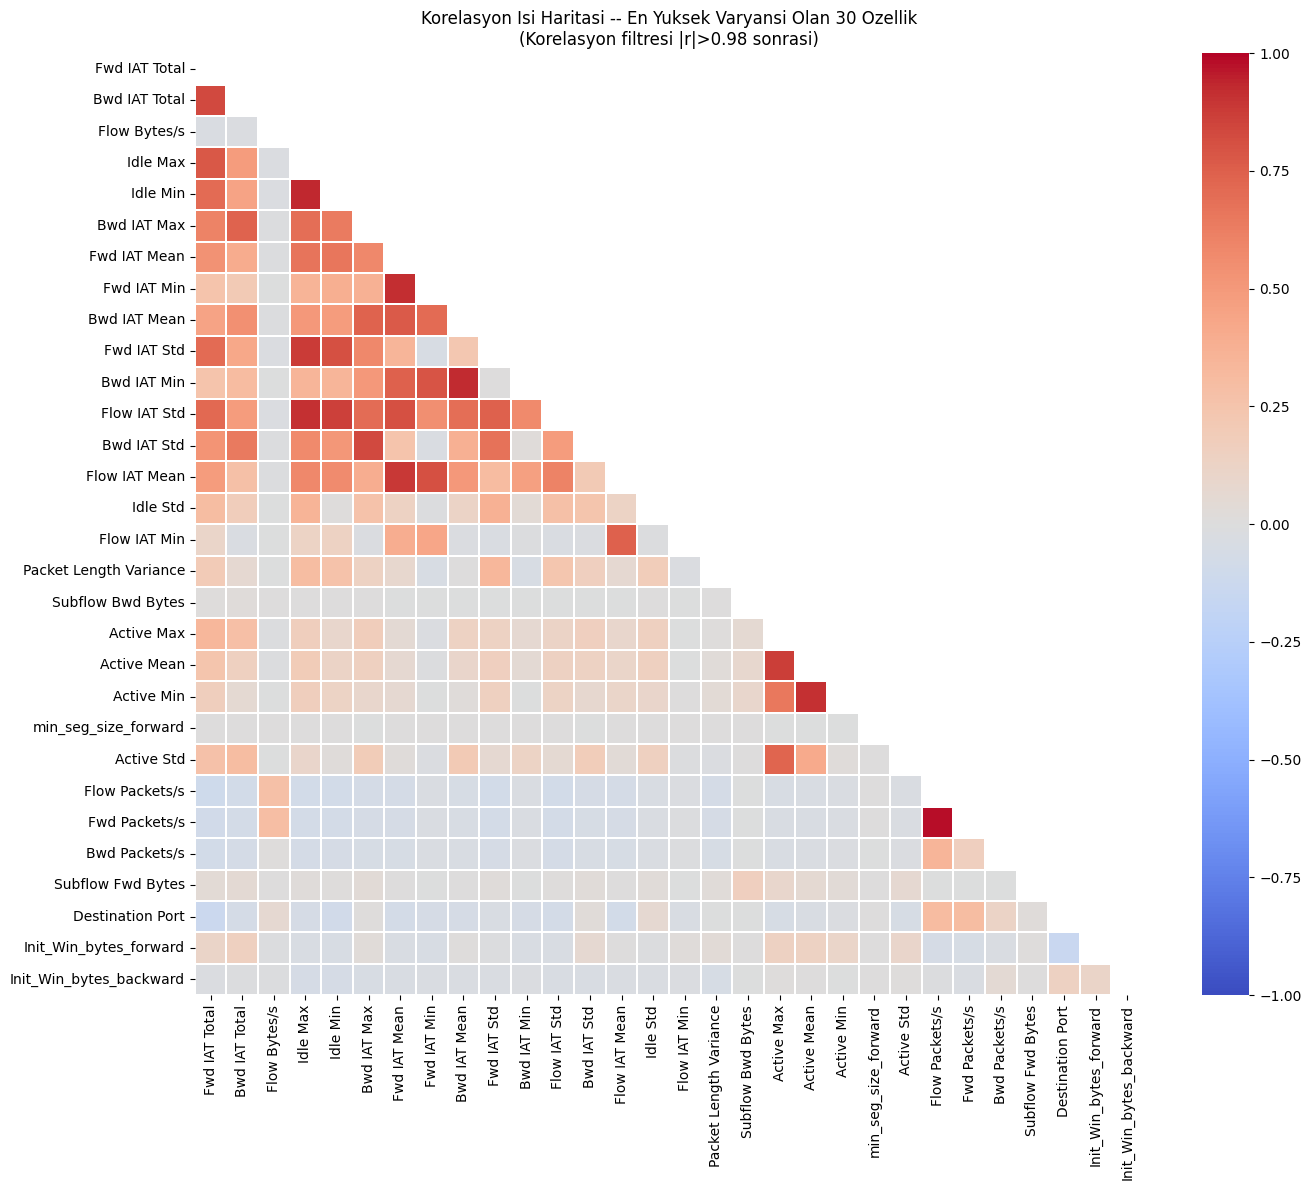

v Korelasyon haritasi kaydedildi: ../data/csv/correlation_heatmap.png


In [12]:
# 8a. Korelasyon isi haritasi (en yuksek varyansi olan top 30 ozellik)
top30_by_var = (
    df[feature_cols].var()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)

corr_top30 = df[top30_by_var].corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_top30, dtype=bool))
sns.heatmap(
    corr_top30, mask=mask, cmap="coolwarm", center=0,
    vmin=-1, vmax=1, linewidths=0.3,
    annot=False, ax=ax
)
ax.set_title(
    f"Korelasyon Isi Haritasi -- En Yuksek Varyansi Olan 30 Ozellik\n"
    f"(Korelasyon filtresi |r|>{CORR_THRESHOLD} sonrasi)",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../data/csv/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("v Korelasyon haritasi kaydedildi: ../data/csv/correlation_heatmap.png")

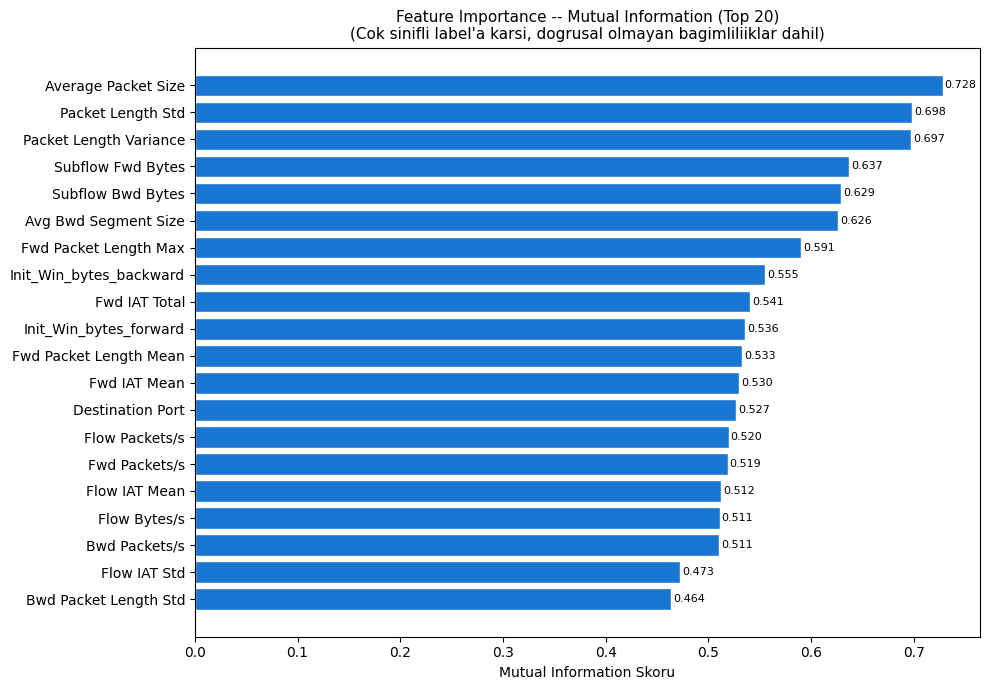

v Feature importance grafigi kaydedildi: ../data/csv/feature_importance_mi.png


In [13]:
# 8b. Feature Importance (Mutual Information -- Top 20)
mi_df_filtered = mi_df[mi_df["feature"].isin(feature_cols)].copy()
top20_mi = mi_df_filtered.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top20_mi["feature"][::-1],
    top20_mi["mi_score"][::-1],
    color="#1976D2", edgecolor="white"
)
ax.set_xlabel("Mutual Information Skoru")
ax.set_title(
    "Feature Importance -- Mutual Information (Top 20)\n"
    "(Cok sinifli label'a karsi, dogrusal olmayan bagimliliiklar dahil)",
    fontsize=11
)
for bar, val in zip(bars, top20_mi["mi_score"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.savefig("../data/csv/feature_importance_mi.png", dpi=150, bbox_inches="tight")
plt.show()
print("v Feature importance grafigi kaydedildi: ../data/csv/feature_importance_mi.png")

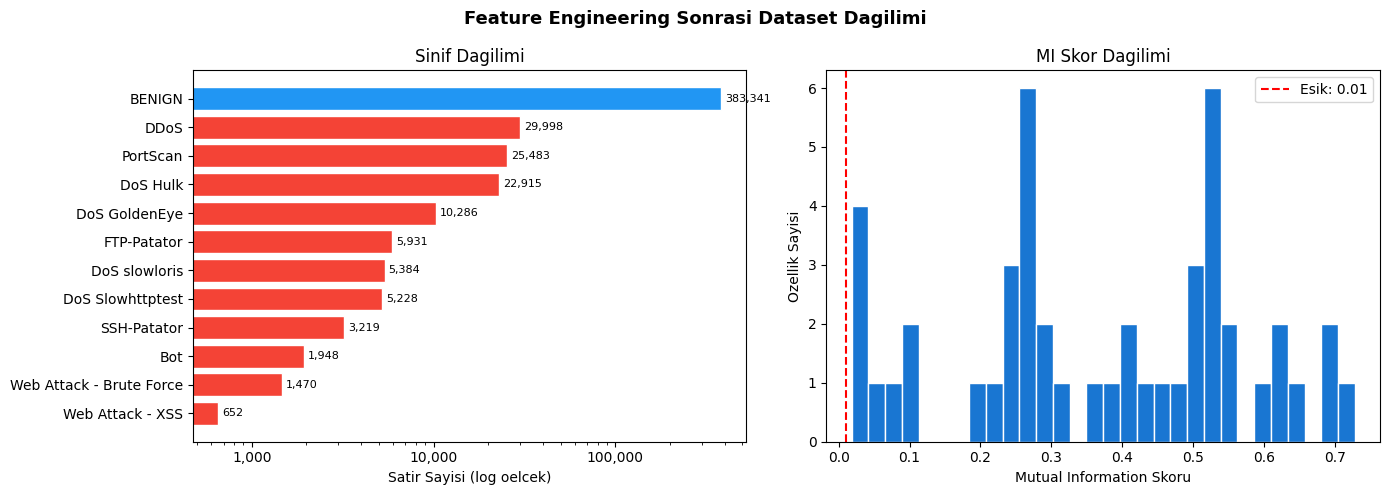

v Grafik kaydedildi: ../data/csv/featured_distribution.png


In [14]:
# 8c. Final sinif dagilimi + MI skor histogrami
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Engineering Sonrasi Dataset Dagilimi", fontsize=13, fontweight="bold")

final_label_dist = df["Label"].value_counts()

# Sol: sinif dagilimi
ax = axes[0]
labels_p = final_label_dist.index.tolist()
counts_p = final_label_dist.values.tolist()
colors_p = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_p]
bars = ax.barh(labels_p[::-1], counts_p[::-1], color=colors_p[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Satir Sayisi (log oelcek)")
ax.set_title("Sinif Dagilimi")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars, counts_p[::-1]):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", ha="left", fontsize=8)

# Sag: MI skor histogrami
ax = axes[1]
ax.hist(mi_df_filtered["mi_score"], bins=30, color="#1976D2", edgecolor="white")
ax.axvline(MI_THRESHOLD, color="red", linestyle="--",
           label=f"Esik: {MI_THRESHOLD}")
ax.set_xlabel("Mutual Information Skoru")
ax.set_ylabel("Ozellik Sayisi")
ax.set_title("MI Skor Dagilimi")
ax.legend()

plt.tight_layout()
plt.savefig("../data/csv/featured_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("v Grafik kaydedildi: ../data/csv/featured_distribution.png")

## 9. Final Ozellik Seti Ozeti

In [15]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("label_multiclass", "label_binary")]

print("=" * 65)
print("FINAL OZELLIK SETI OZETI")
print("=" * 65)
print(f"  Baslangic (02 ciktisi)           : {df.shape[1] - 3} numerik ozellik")
print(f"  Duplicate silme                  : bkz. Adim 2")
print(f"  Korelasyon filtresi (|r|>{CORR_THRESHOLD}) : bkz. Adim 3")
print(f"  MI filtresi (MI<{MI_THRESHOLD})           : bkz. Adim 5")
print(f"  FINAL numerik ozellik sayisi     : {len(feature_cols)}")
print()
print("Secilen ozellikler (MI sirasina gore):")
print(f"  {'#':<4} {'Ozellik':<45} {'MI Skoru':>10}")
print("-" * 62)
mi_ranked = mi_df[mi_df["feature"].isin(feature_cols)].sort_values("mi_score", ascending=False)
for rank, (_, row) in enumerate(mi_ranked.iterrows(), 1):
    print(f"  {rank:<4} {row['feature']:<45} {row['mi_score']:>10.4f}")

FINAL OZELLIK SETI OZETI
  Baslangic (02 ciktisi)           : 48 numerik ozellik
  Duplicate silme                  : bkz. Adim 2
  Korelasyon filtresi (|r|>0.98) : bkz. Adim 3
  MI filtresi (MI<0.01)           : bkz. Adim 5
  FINAL numerik ozellik sayisi     : 47

Secilen ozellikler (MI sirasina gore):
  #    Ozellik                                         MI Skoru
--------------------------------------------------------------
  1    Average Packet Size                               0.7282
  2    Packet Length Std                                 0.6983
  3    Packet Length Variance                            0.6972
  4    Subflow Fwd Bytes                                 0.6369
  5    Subflow Bwd Bytes                                 0.6290
  6    Avg Bwd Segment Size                              0.6260
  7    Fwd Packet Length Max                             0.5905
  8    Init_Win_bytes_backward                           0.5554
  9    Fwd IAT Total                                    

## 10. Kalite Kontrol

In [16]:
print("=" * 60)
print("KALITE KONTROL")
print("=" * 60)

# 1. NaN yok
assert df.isnull().sum().sum() == 0, "HATA: NaN var!"
print("v NaN yok")

# 2. Inf yok
num_check = df.select_dtypes(include=[np.number]).columns
assert not np.isinf(df[num_check].values).any(), "HATA: Inf var!"
print("v Inf yok")

# 3. Sifir-varyans sUtun yok
zv = [c for c in feature_cols if df[c].nunique() <= 1]
assert len(zv) == 0, f"HATA: Sifir-varyans sutun var: {zv}"
print("v Sifir-varyans sutun yok")

# 4. label_multiclass ve label_binary tutarli
n_mc = df["label_multiclass"].nunique()
n_lb = df["label_binary"].nunique()
assert n_mc >= 2, f"HATA: Multiclass label tek deger: {n_mc}"
assert n_lb == 2, f"HATA: Binary label 2 deger icermeli: {n_lb}"
print(f"v label_multiclass: {n_mc} sinif")
print(f"v label_binary: 2 sinif")

# 5. Label string ile LabelEncoder tutarli
assert set(df["Label"].unique()) == set(le.classes_), \
    "HATA: Label string ile LabelEncoder siniflari uyusmuyor!"
print("v Label string <-> label_multiclass tutarli")

# 6. Ozellik sayisi makul (10-100 arasi beklenir)
assert 10 <= len(feature_cols) <= 100, \
    f"HATA: Ozellik sayisi beklenen aralik disinda: {len(feature_cols)}"
print(f"v Ozellik sayisi makul: {len(feature_cols)}")

# 7. Yuksek korelasyon kalmamali
corr_check = df[feature_cols].corr().abs()
upper_check = corr_check.where(
    np.triu(np.ones(corr_check.shape), k=1).astype(bool)
)
max_remaining_corr = upper_check.max().max()
if max_remaining_corr > CORR_THRESHOLD + 0.005:
    print(f"! Uyari: Hala yuksek korelasyon var: {max_remaining_corr:.4f}")
else:
    print(f"v Maksimum kalan korelasyon: {max_remaining_corr:.4f}")

# 8. Benign orani makul
total = len(df)
n_b   = (df["label_binary"] == 0).sum()
benign_pct = n_b / total * 100
assert 40 <= benign_pct <= 90, f"HATA: Benign orani anormal -> %{benign_pct:.1f}"
print(f"v Benign orani makul: %{benign_pct:.1f}")

print()
print("=" * 60)
print("OZET")
print("=" * 60)
print(f"  Satir          : {total:>9,}")
print(f"  Ozellik sayisi : {len(feature_cols)}")
print(f"  Sinif sayisi   : {n_mc}")
print(f"  Benign orani   : %{benign_pct:.1f}")
print()
print("=" * 60)
print("DATASET HAZIR -> sonraki adim: 04_modeling.ipynb")
print("=" * 60)

KALITE KONTROL
v NaN yok
v Inf yok
v Sifir-varyans sutun yok
v label_multiclass: 12 sinif
v label_binary: 2 sinif
v Label string <-> label_multiclass tutarli
v Ozellik sayisi makul: 47
v Maksimum kalan korelasyon: 0.9793
v Benign orani makul: %77.3

OZET
  Satir          :   495,855
  Ozellik sayisi : 47
  Sinif sayisi   : 12
  Benign orani   : %77.3

DATASET HAZIR -> sonraki adim: 04_modeling.ipynb


## 11. Kaydetme

In [17]:
# 1. Ana dataset (secilmis feature + label sutunlari)
cols_to_save = feature_cols + ["Label", "label_multiclass", "label_binary"]
if "source_file" in df.columns:
    cols_to_save.append("source_file")

df[cols_to_save].to_csv(OUTPUT_DATASET, index=False)
size_mb = os.path.getsize(OUTPUT_DATASET) / (1024 * 1024)
print(f"v Featured dataset kaydedildi : {OUTPUT_DATASET}")
print(f"  Boyut  : {size_mb:.1f} MB")
print(f"  Satir  : {len(df):,}")
print(f"  Sutun  : {len(cols_to_save)}")

# 2. Ozellik listesi (04_modeling'de dogrudan import icin)
with open(OUTPUT_FEATURES_TXT, "w") as f_out:
    for feat in sorted(feature_cols):
        f_out.write(feat + "\n")
print(f"\nv Ozellik listesi kaydedildi  : {OUTPUT_FEATURES_TXT}")
print(f"  {len(feature_cols)} ozellik")

# 3. Label esleme tablosu
label_mapping.to_csv(OUTPUT_LABEL_MAP, index=False)
print(f"\nv Label esleme tablosu        : {OUTPUT_LABEL_MAP}")
print()
print(label_mapping.to_string(index=False))

v Featured dataset kaydedildi : ../data/csv/featured_dataset.csv
  Boyut  : 140.1 MB
  Satir  : 495,855
  Sutun  : 51

v Ozellik listesi kaydedildi  : ../data/csv/selected_features.txt
  47 ozellik

v Label esleme tablosu        : ../data/csv/label_mapping.csv

 label_int             label_string
         0                   BENIGN
         1                      Bot
         2                     DDoS
         3            DoS GoldenEye
         4                 DoS Hulk
         5         DoS Slowhttptest
         6            DoS slowloris
         7              FTP-Patator
         8                 PortScan
         9              SSH-Patator
        10 Web Attack - Brute Force
        11         Web Attack - XSS
